In [1]:
import networkx as nx
import networkx.algorithms.community as nx_comm
import csv
import numpy as np

import matplotlib.pyplot as plt

import timeit

In [2]:
base_network_path = "./Base.gexf"
labels_file = "../ogbn-arxiv/raw/node-label.csv"
years_file = "../ogbn-arxiv/raw/node_year.csv"
features_file = "../ogbn-arxiv/raw/node_year.csv"

In [3]:
with open(labels_file, "r") as file:
    labels_content = np.array(list(csv.reader(file)), dtype=np.int8)

with open(years_file, "r") as file:
    years_content = np.array(list(csv.reader(file)), dtype=np.int16)

In [4]:
label_counts = np.unique_counts(labels_content)
years_counts = np.unique_counts(years_content)

In [5]:
label_counts

UniqueCountsResult(values=array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39], dtype=int8), counts=array([  565,   687,  4839,  2080,  5862,  4958,  1618,   589,  6232,
        2820,  7869,   750,    29,  2358,   597,   403, 27321,   515,
         749,  2877,  2076,   393,  1903,  2834, 22187,  1257,  4605,
        4801, 21406,   416, 11814,  2828,   411,  1271,  7867,   127,
        3524,  2369,  1507,  2029]))

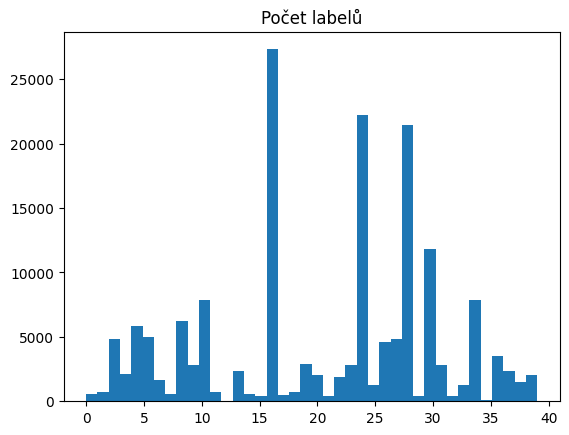

In [6]:
plt.title("Počet labelů")
plt.hist(labels_content, bins=40)
plt.show()

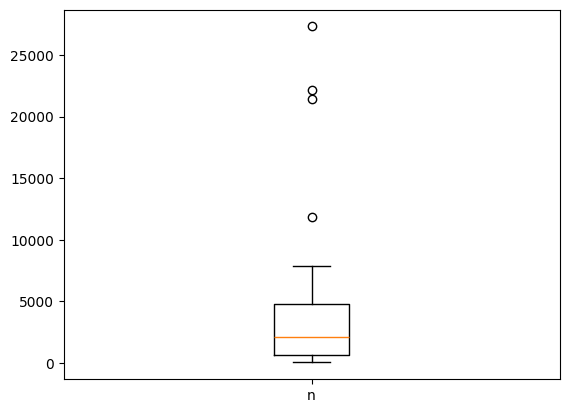

In [7]:
plt.title("")
plt.boxplot(label_counts.counts, tick_labels=["n"])
plt.show()

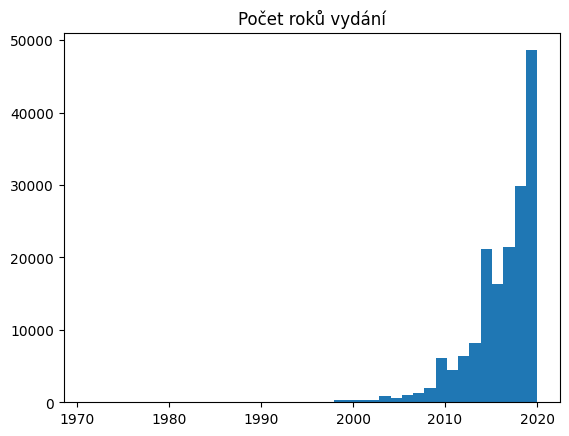

In [8]:
plt.title("Počet roků vydání")
plt.hist(years_content, bins=40)
plt.show()

# Detekce komunit

## Louvain

In [ ]:
G: nx.Graph = nx.read_gexf(base_network_path)
communities_louvain = nx_comm.louvain_communities(G, seed=42)
communities_louvain[:5]

[{'100086',
  '100154',
  '100176',
  '100234',
  '100269',
  '100507',
  '100759',
  '100793',
  '101243',
  '101355',
  '101388',
  '101636',
  '102046',
  '10223',
  '102278',
  '103207',
  '103237',
  '104070',
  '104496',
  '104497',
  '105114',
  '105348',
  '106021',
  '106687',
  '107173',
  '107285',
  '107318',
  '108133',
  '108154',
  '108644',
  '108799',
  '108839',
  '109148',
  '109357',
  '109559',
  '109934',
  '110023',
  '110988',
  '111148',
  '111191',
  '111274',
  '111287',
  '111778',
  '111992',
  '112527',
  '112577',
  '112627',
  '11314',
  '113821',
  '113832',
  '113833',
  '113939',
  '114759',
  '114837',
  '114882',
  '114948',
  '115199',
  '115301',
  '115327',
  '115356',
  '115922',
  '116253',
  '116716',
  '116820',
  '11691',
  '117321',
  '11743',
  '118052',
  '11846',
  '118680',
  '118849',
  '119141',
  '119142',
  '119195',
  '119238',
  '119574',
  '119819',
  '119886',
  '120376',
  '120536',
  '120553',
  '120720',
  '121018',
  '121592

In [11]:
len(communities_louvain)

159

Bylo nalezeno 159 komunit, což je mnohem více, než kolik je v datech tříd (40).

In [42]:
# Vložení ground truth do souboru
nx.set_node_attributes(G, {node: {"ground_truth": labels_content[int(node)][0]} for node in G.nodes})

In [ ]:
# Vložení idx komunity nalezené pomocí funkce
for idx, community in enumerate(communities_louvain):
    for node in community:
        nx.set_node_attributes(G, {node: {"louvain": idx}})

In [44]:
print(G.nodes["0"]["ground_truth"], G.nodes["0"]["louvain"])

4 120


Nalezené komunity nebudou přesně reflektovat ground_truth. Budu testovat oproti nejčetnější komunitě pro třídu

In [46]:
from collections import defaultdict

In [51]:
true_pred = defaultdict(list[int])
for node in G.nodes:
    node_data = G.nodes[node]
    true_ = node_data["ground_truth"]
    predicted = node_data["louvain"]
    true_pred[true_].append(predicted)

Pro zjištění nejčetnějšího labelu využiji bincount + argmax. V některých případech se může stát, že se ground_truth rozdělí na více velkých částí.

In [ ]:
np.bincount(true_pred[0])

array([  2,   6,   0,   7,   0,   0, 144, 113,   0,   1,   0,   0,   0,
         0,   0, 107,   0,   0,   0,   1,   0,   0,   2,   1,   0,   0,
         0,  16,   0,   0,   0,   0,   0,   0,   4,   0,   0,   0,  15,
         6,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   3,   0,   0,  11,   0,   0,   0,   0,   6,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,  24,   0,   0,   0,   0,   0,   0,   0,   0,   1,   0,   1,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  20,   0,
         0,   0,   4,   0,   0,   0,   0,   2,   0,   0,   0,   0,   0,
        14,   0,   0,   1,  38,   4,   0,   0,   0,   0,   0,   0,   0,
         0,   2,   0,   0,   6,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3])

zde lze vidět, že nejčetnější louvain komunity jsou [6, 7, 15]

In [111]:
counts = np.bincount(true_pred[0])
# Labely, které jsou >= max-0.3max (rozmezí <0.3max; max>)
np.where((counts >= counts.max() - counts.max()*0.3))[0]

array([ 6,  7, 15])

In [127]:
np.bincount(true_pred[0]).max() / len(true_pred[0])

np.float64(0.25486725663716814)

Můžeme říct, že pro třídu 0 má louvain accuracy ~25%?

Co když budeme testovat proti dříve definovanému rozmezí? Můžeme to udělat?

In [147]:
accuracies = []
for label, preds in true_pred.items():
    # print(preds)
    preds_num = np.bincount(preds).max()
    accuracies.insert(label, preds_num / len(preds))

accuracies = np.array(accuracies)
accuracies

array([0.25486726, 0.16302766, 0.13473424, 0.25673077, 0.52659127,
       0.72494317, 0.62310919, 0.26315789, 0.2833804 , 0.37546912,
       0.32639379, 0.50567376, 0.24137931, 0.54813864, 0.32666667,
       0.3101737 , 0.51504251, 0.39029126, 0.17257854, 0.62646566,
       0.41255007, 0.31503368, 0.7478434 , 0.27905004, 0.11959288,
       0.74267101, 0.56009165, 0.42322991, 0.27181091, 0.53721045,
       0.65002627, 0.86092771, 0.17307692, 0.78949904, 0.63195233,
       0.27100042, 0.36810467, 0.82297404, 0.4015748 , 0.36009732])

Některé třídy jsou poměrně dobře napamované s accuracy ~80%.

In [150]:
accuracies.sum() / len(accuracies)

np.float64(0.4326783078548275)

Objevují se louvain komunity i v jiných třídách?

In [156]:
len(set([a for a in true_pred[0] if a in true_pred[1]]))

19

Ano, určitě. Třídy 0 a 1 mají 19 společných komunit. Jak se s tímto vypořádat?

### Spočtení metrik NMI, ARI a F1

In [158]:
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, f1_score

In [162]:
y_true = []
y_pred = []

for node in G.nodes:
    node_data = G.nodes[node]
    y_true.append(node_data["ground_truth"])
    y_pred.append(node_data["louvain"])

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [163]:
nmi = normalized_mutual_info_score(y_true, y_pred)
ari = adjusted_rand_score(y_true, y_pred)

print(f"NMI: {nmi:.4f}")
print(f"ARI: {ari:.4f}")

NMI: 0.4020
ARI: 0.2838


In [189]:
from scipy.optimize import linear_sum_assignment

In [ ]:
true_labels = np.unique(y_true)
pred_labels = np.unique(y_pred)

# kontingenční matice (komunity × třídy)
cost_matrix = np.zeros((len(pred_labels), len(true_labels)))

for i, p in enumerate(pred_labels):
    for j, t in enumerate(true_labels):
        cost_matrix[i, j] = np.sum((y_pred == p) & (y_true == t))

# ===== Hungarian mapping =====
row_ind, col_ind = linear_sum_assignment(-cost_matrix)

mapping = {pred_labels[row]: true_labels[col] for row, col in zip(row_ind, col_ind)}

# ===== doplnění chybějících komunit =====
for p in pred_labels:
    if p not in mapping:
        mask = (y_pred == p)
        majority_class = np.bincount(y_true[mask]).argmax()
        mapping[p] = majority_class

# ===== přemapování =====
y_pred_mapped = np.array([mapping[p] for p in y_pred])

# ===== F1 =====
macro_f1 = f1_score(y_true, y_pred_mapped, average='macro')

print(f"Macro-F1: {macro_f1:.4f}")

Macro-F1: 0.2158


### Výsledné evaluační metriky pro louvain komunity:
|NMI|ARI|F1-MACRO|
|--|--|--|
|0.4020|0.2838|0.2158|

#### Uložení do gephy souboru (pro vizualizace)

In [191]:
nx.write_gexf(G, "communities.gexf")